In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/alitaqishah/nvidia-stock-data-19992026-the-ai-mega-stock/nvidia_stock_data_1999_2026.csv


In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('/kaggle/input/datasets/alitaqishah/nvidia-stock-data-19992026-the-ai-mega-stock/nvidia_stock_data_1999_2026.csv')
df

,date,open,high,low,close,volume,shares_outstanding_bn,market_cap_usd_bn,quarterly_revenue_usd_bn,sma_20,sma_50,sma_200,rsi_14,stock_split,era,key_event
0,22/01/1999,0.0314,0.0315,0.0312,0.0313,4156178,0.600,0.02,1.33,0.0317,0.0294,0.0312,42.6,NaN,Pre-GPU Era,NVDA IPO on NASDAQ
1,25/01/1999,0.0310,0.0317,0.0308,0.0313,17362290,0.614,0.02,1.92,0.0312,0.0333,0.0349,59.9,NaN,Pre-GPU Era,NVDA IPO on NASDAQ
2,26/01/1999,0.0315,0.0318,0.0312,0.0315,10531814,0.612,0.02,2.17,0.0327,0.0299,0.0359,58.4,NaN,Pre-GPU Era,NVDA IPO on NASDAQ
3,27/01/1999,0.0315,0.0319,0.0309,0.0314,14602646,0.618,0.02,1.00,0.0309,0.0293,0.0292,45.4,NaN,Pre-GPU Era,NVDA IPO on NASDAQ
4,28/01/1999,0.0313,0.0315,0.0313,0.0314,19343208,0.602,0.02,1.53,0.0305,0.0294,0.0327,40.2,NaN,Pre-GPU Era,NVDA IPO on NASDAQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7074,05/03/2026,18.6213,18.7486,18.4836,18.6045,367124062,24.407,454.08,3.56,18.1687,19.6907,20.4758,72.0,NaN,Generative AI Era,GTC 2026 Conference
7075,06/03/2026,18.6526,18.8220,18.2728,18.5820,504535560,24.598,457.08,2.17,18.3558,19.5697,15.9392,60.7,NaN,Generative AI Era,GTC 2026 Conference
7076,09/03/2026,18.7442,18.8885,18.2919,18.5577,498401332,24.576,456.07,3.31,18.7405,19.3031,18.5745,73.1,NaN,Generative AI Era,GTC 2026 Conference
7077,10/03/2026,18.4700,18.6028,18.4124,18.5336,416851111,24.419,452.57,2.80,18.7126,19.7673,17.6331,67.9,NaN,Generative AI Era,GTC 2026 Conference


In [3]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)


df = df.sort_values('date')


df.isnull().sum()



date                           0
open                           0
high                           0
low                            0
close                          0
volume                         0
shares_outstanding_bn          0
market_cap_usd_bn              0
quarterly_revenue_usd_bn       0
sma_20                         0
sma_50                         0
sma_200                        0
rsi_14                         0
stock_split                 7073
era                            0
key_event                   6826
dtype: int64

In [4]:
df.fillna("True")

,date,open,high,low,close,volume,shares_outstanding_bn,market_cap_usd_bn,quarterly_revenue_usd_bn,sma_20,sma_50,sma_200,rsi_14,stock_split,era,key_event
0,1999-01-22,0.0314,0.0315,0.0312,0.0313,4156178,0.600,0.02,1.33,0.0317,0.0294,0.0312,42.6,True,Pre-GPU Era,NVDA IPO on NASDAQ
1,1999-01-25,0.0310,0.0317,0.0308,0.0313,17362290,0.614,0.02,1.92,0.0312,0.0333,0.0349,59.9,True,Pre-GPU Era,NVDA IPO on NASDAQ
2,1999-01-26,0.0315,0.0318,0.0312,0.0315,10531814,0.612,0.02,2.17,0.0327,0.0299,0.0359,58.4,True,Pre-GPU Era,NVDA IPO on NASDAQ
3,1999-01-27,0.0315,0.0319,0.0309,0.0314,14602646,0.618,0.02,1.00,0.0309,0.0293,0.0292,45.4,True,Pre-GPU Era,NVDA IPO on NASDAQ
4,1999-01-28,0.0313,0.0315,0.0313,0.0314,19343208,0.602,0.02,1.53,0.0305,0.0294,0.0327,40.2,True,Pre-GPU Era,NVDA IPO on NASDAQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7074,2026-03-05,18.6213,18.7486,18.4836,18.6045,367124062,24.407,454.08,3.56,18.1687,19.6907,20.4758,72.0,True,Generative AI Era,GTC 2026 Conference
7075,2026-03-06,18.6526,18.8220,18.2728,18.5820,504535560,24.598,457.08,2.17,18.3558,19.5697,15.9392,60.7,True,Generative AI Era,GTC 2026 Conference
7076,2026-03-09,18.7442,18.8885,18.2919,18.5577,498401332,24.576,456.07,3.31,18.7405,19.3031,18.5745,73.1,True,Generative AI Era,GTC 2026 Conference
7077,2026-03-10,18.4700,18.6028,18.4124,18.5336,416851111,24.419,452.57,2.80,18.7126,19.7673,17.6331,67.9,True,Generative AI Era,GTC 2026 Conference


After changing the Date to Datetime and filling in the missing values now we move on to EDA

In [5]:
df.era.unique()

array(['Pre-GPU Era', 'Gaming GPU Era', 'Deep Learning Era',
       'Data Center Growth', 'Generative AI Era'], dtype=object)

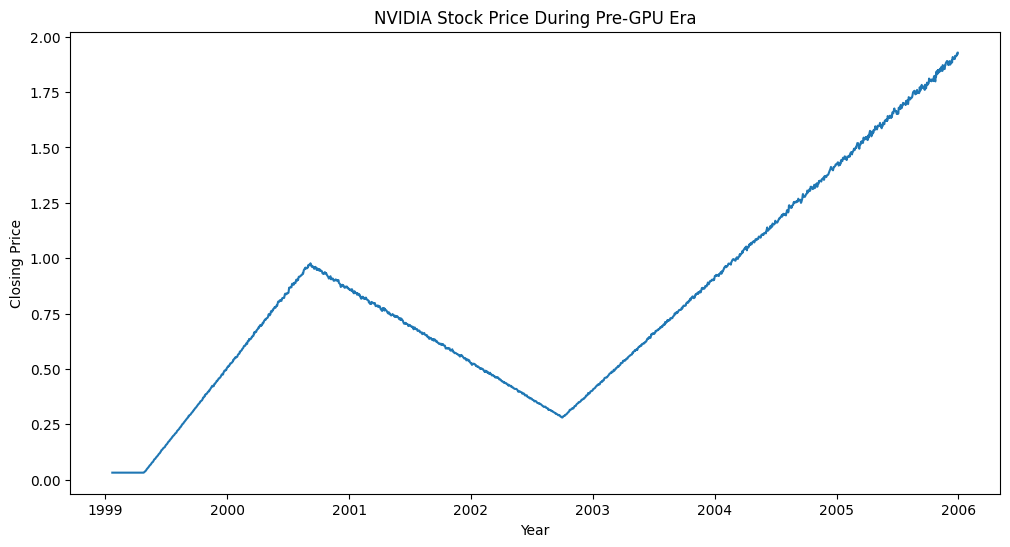

In [6]:
import matplotlib.pyplot as plt
pgpu=df[df['era']=="Pre-GPU Era"]
plt.figure(figsize=(12,6))

plt.plot(pgpu['date'], pgpu['close'])

plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.title("NVIDIA Stock Price During Pre-GPU Era")

plt.show()

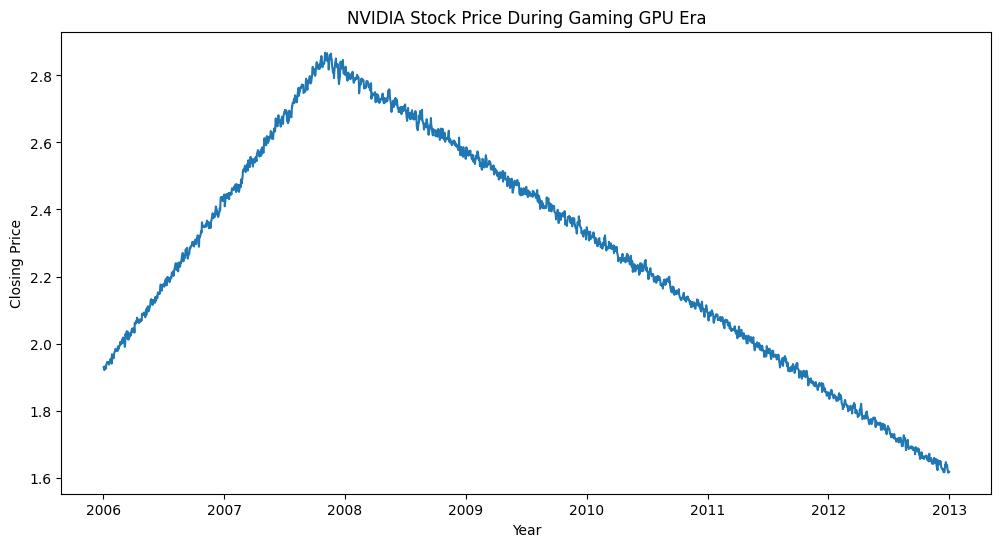

In [7]:
gera=df[df['era']=="Gaming GPU Era"]
plt.figure(figsize=(12,6))

plt.plot(gera['date'], gera['close'])

plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.title("NVIDIA Stock Price During Gaming GPU Era")

plt.show()

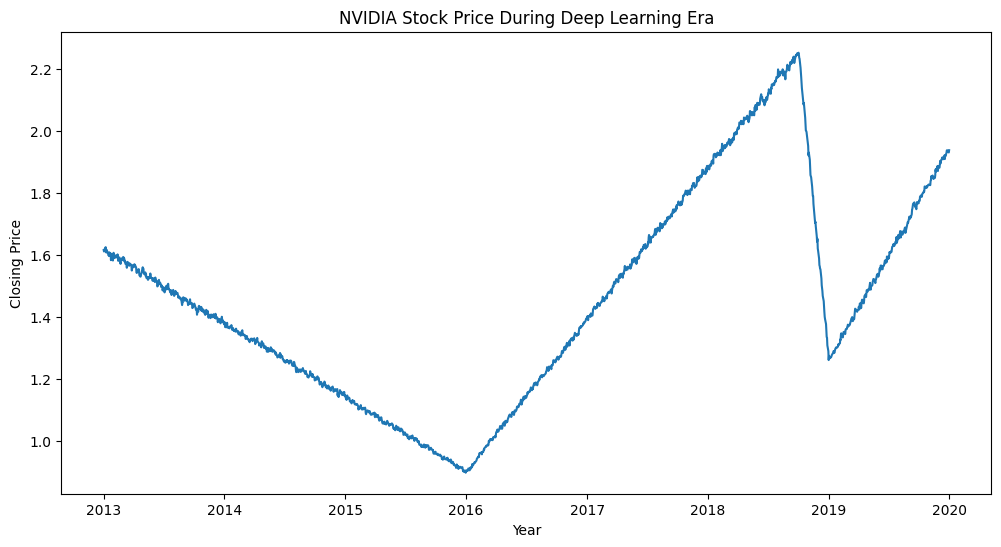

In [8]:
dera=df[df['era']=="Deep Learning Era"]
plt.figure(figsize=(12,6))

plt.plot(dera['date'], dera['close'])

plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.title("NVIDIA Stock Price During Deep Learning Era")

plt.show()

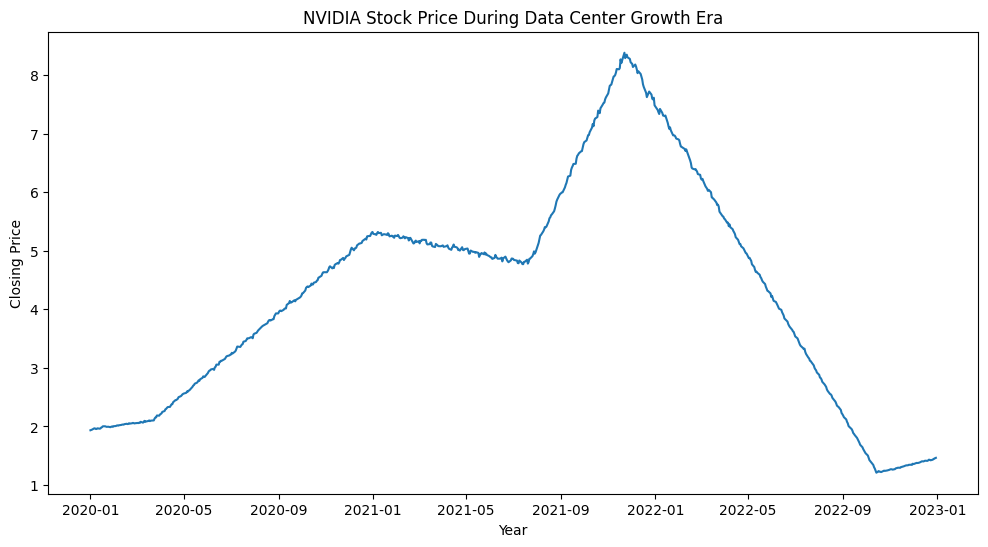

In [9]:
dcera=df[df['era']=="Data Center Growth"]
plt.figure(figsize=(12,6))

plt.plot(dcera['date'], dcera['close'])

plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.title("NVIDIA Stock Price During Data Center Growth Era")

plt.show()

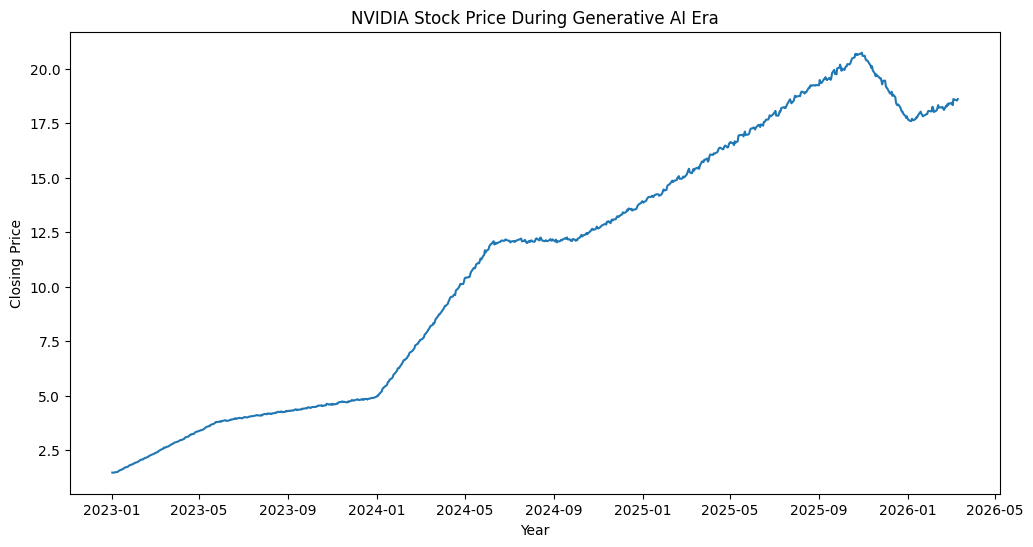

In [10]:
gaera=df[df['era']=="Generative AI Era"]
plt.figure(figsize=(12,6))

plt.plot(gaera['date'], gaera['close'])

plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.title("NVIDIA Stock Price During Generative AI Era")

plt.show()

From the above graphs, we get to know that the NVIDIA Stock price grew multifold during the Generative AI Era, where the stock grew 1340% over the span of 3 years

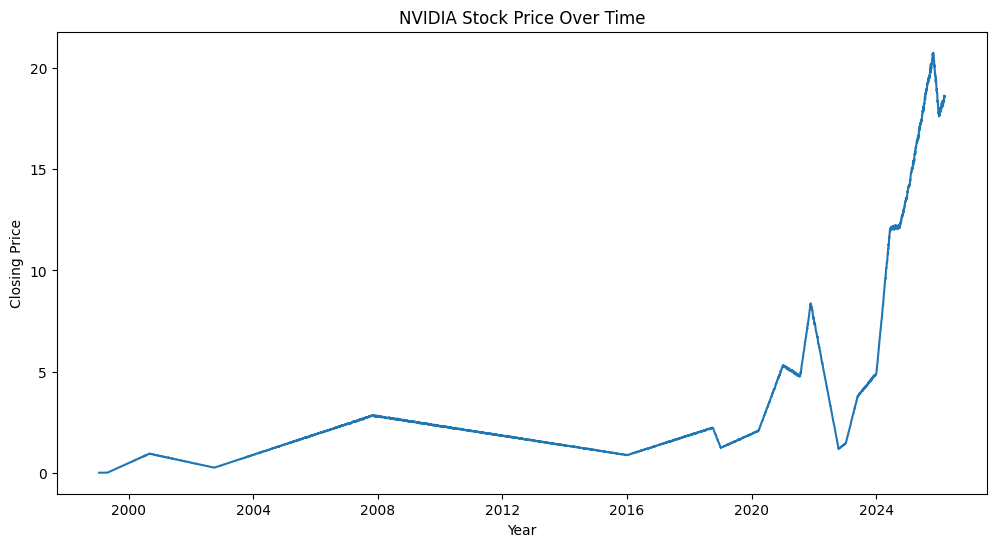

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['close'])
plt.title("NVIDIA Stock Price Over Time")
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.show()

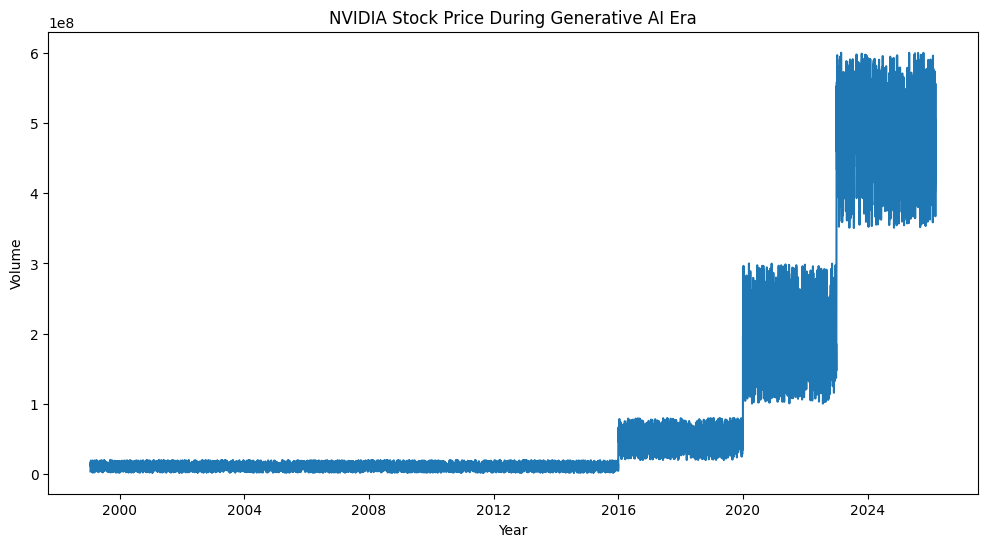

In [12]:

plt.figure(figsize=(12,6))

plt.plot(df['date'], df['volume'])

plt.xlabel("Year")
plt.ylabel("Volume")
plt.title("NVIDIA Stock Price During Generative AI Era")

plt.show()

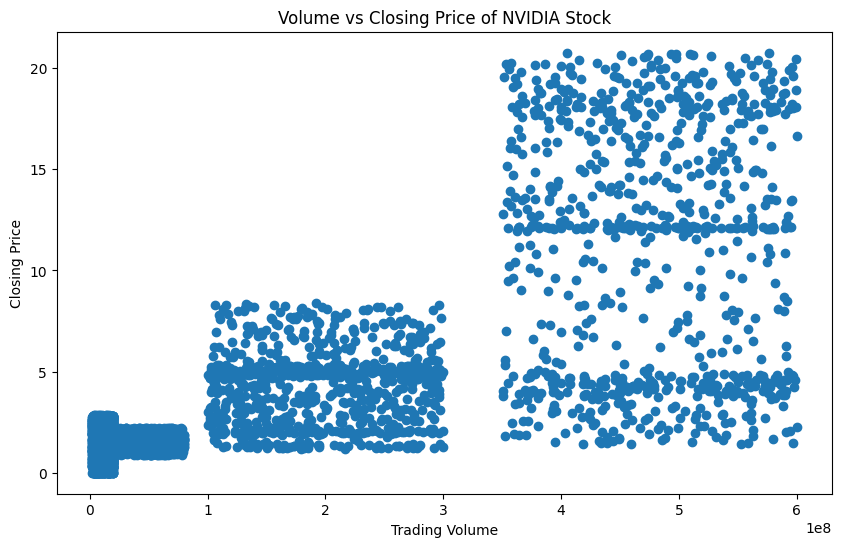

In [13]:

plt.figure(figsize=(10,6))

plt.scatter(df['volume'], df['close'])

plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")
plt.title("Volume vs Closing Price of NVIDIA Stock")

plt.show()

In the above 2 graphs, we have compared **"Volume v/s Year"** and **"Volume v/s Closing price"**. We can observe that the **volume of shares** has increased in **2016,2020** and **2023**. This spike in the graph correlates to the major technological and market events. 
* 2016- NVIDIA’s Pascal GPU architecture accelerated deep learning adoption
* 2020- COVID-19 pandemic, RTX 3000 GPU launch
* 2023- Global Generative AI boom and NVIDIA becoming the dominant hardware supplier for AI training.

News letter for the above events 
* 2016 - [https://nvidianews.nvidia.com/news/new-nvidia-pascal-gpus-accelerate-deep-learning-inference-6622422](https://nvidianews.nvidia.com/news/new-nvidia-pascal-gpus-accelerate-deep-learning-inference-6622422)
* 2020 - [https://www.forbes.com/sites/moorinsights/2020/09/01/nvidias-new-rtx-3000-series--faster-bigger-better-and-more-power-hungry/](https://www.forbes.com/sites/moorinsights/2020/09/01/nvidias-new-rtx-3000-series--faster-bigger-better-and-more-power-hungry/)
* 2023- [https://nvidianews.nvidia.com/news/nvidia-announces-dgx-gh200-ai-supercomputer](https://nvidianews.nvidia.com/news/nvidia-announces-dgx-gh200-ai-supercomputer)

In [14]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


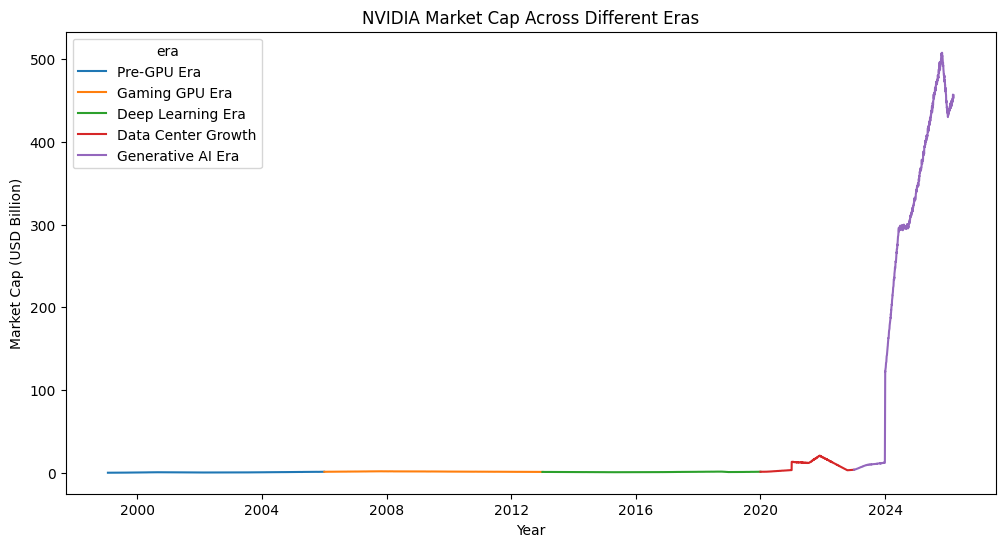

In [15]:
plt.figure(figsize=(12,6))

sns.lineplot(x='date', y='market_cap_usd_bn', hue='era', data=df)

plt.title("NVIDIA Market Cap Across Different Eras")
plt.xlabel("Year")
plt.ylabel("Market Cap (USD Billion)")

plt.show()

Text(0.5, 1.0, 'Market Cap vs Revenue Regression')

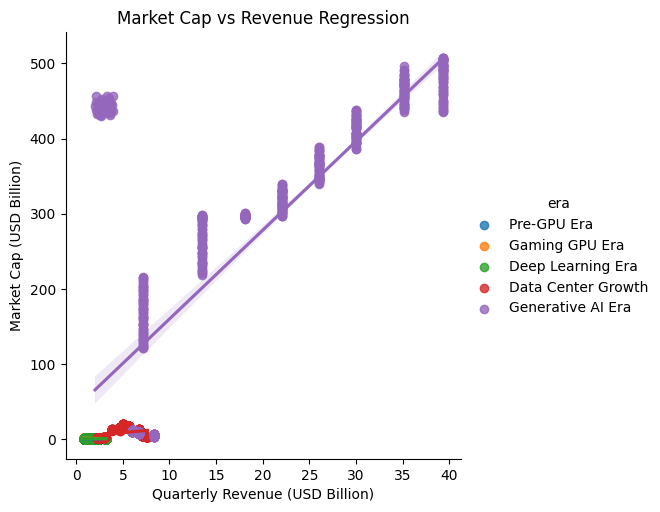

In [16]:
sns.lmplot(x='quarterly_revenue_usd_bn',
            y='market_cap_usd_bn',hue='era',
            data=df)
plt.xlabel("Quarterly Revenue (USD Billion)")
plt.ylabel("Market Cap (USD Billion)")
plt.title("Market Cap vs Revenue Regression")


This graph is the Quaterly revenue v/s Market cap. From the first glance we can figure out. * As the revenue increases the market cap also increases. 
* NVIDIA’s valuation increased significantly during the AI-driven eras compared to earlier GPU-focused periods.
* Market cap grows faster than the revenue which shows that the investors value the stock and indetify good future stock growth. 

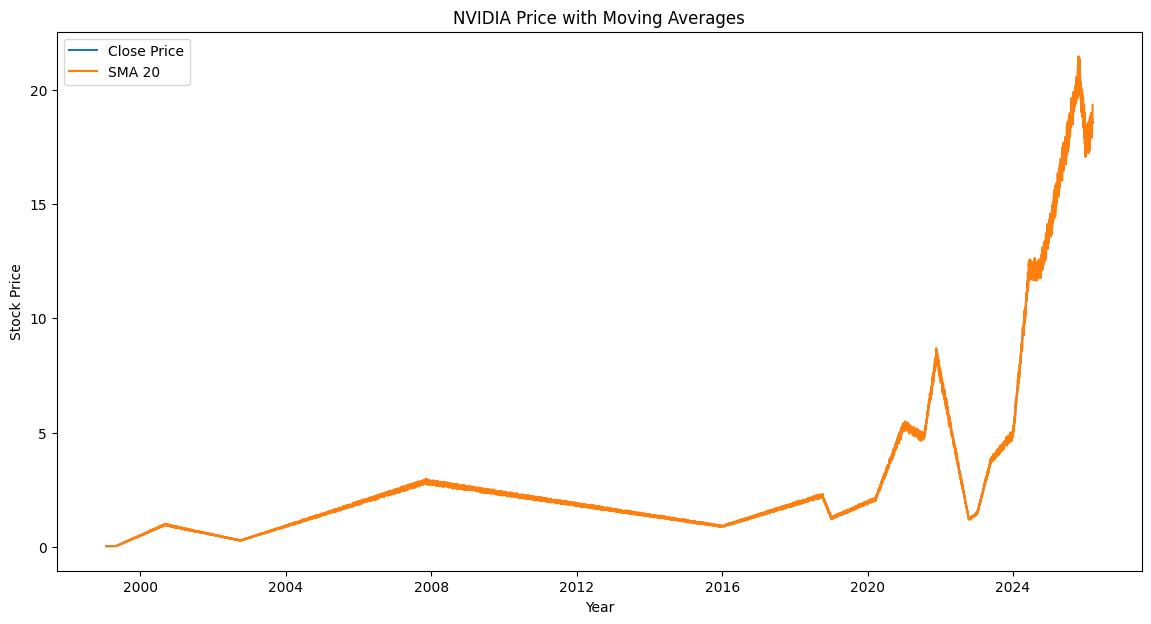

In [17]:
plt.figure(figsize=(14,7))

sns.lineplot(x='date', y='close', data=df, label='Close Price')
sns.lineplot(x='date', y='sma_20', data=df, label='SMA 20')


plt.title("NVIDIA Price with Moving Averages")
plt.xlabel("Year")
plt.ylabel("Stock Price")

plt.show()

Text(0, 0.5, 'Stock Price')

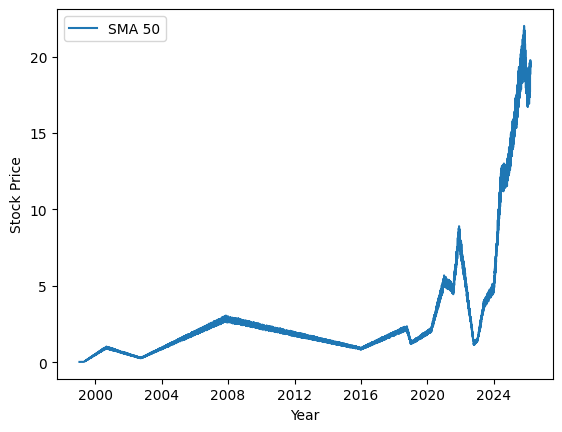

In [18]:
sns.lineplot(x='date', y='sma_50', data=df, label='SMA 50')
plt.xlabel("Year")
plt.ylabel("Stock Price")


Text(0, 0.5, 'Stock Price')

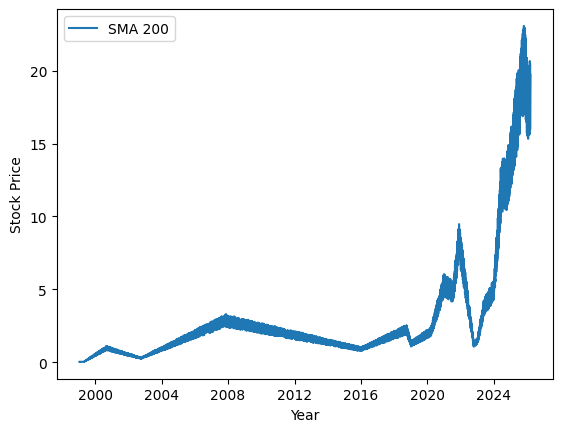

In [19]:
sns.lineplot(x='date', y='sma_200', data=df, label='SMA 200')
plt.xlabel("Year")
plt.ylabel("Stock Price")


The SMA [Simple moving average] shows the stock performance over the given period of time ie(20 , 50 , 200) days 

Text(0.5, 1.0, 'Nvidia stock split ratio v/s count')

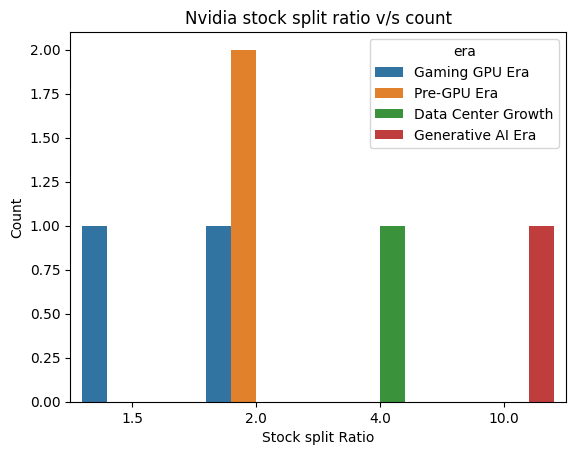

In [20]:
split_data = df[df['stock_split'] > 1]
sns.countplot(data=split_data,x='stock_split',hue='era')
plt.xlabel("Stock split Ratio")
plt.ylabel("Count")
plt.title("Nvidia stock split ratio v/s count")

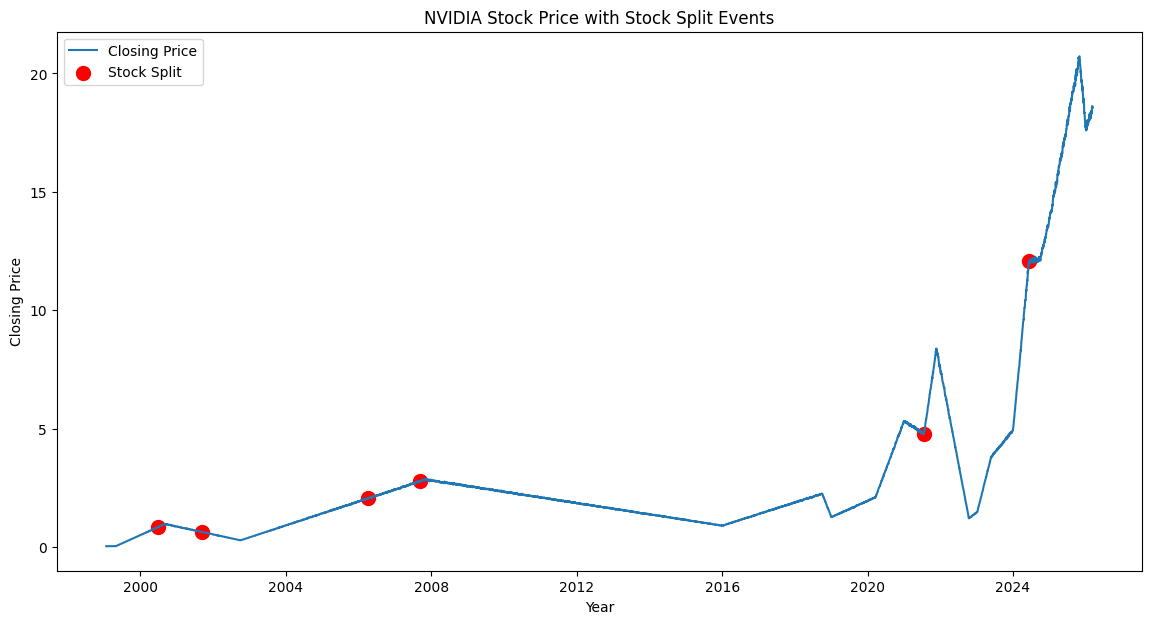

In [21]:
plt.figure(figsize=(14,7))

sns.lineplot(x='date', y='close', data=df, label="Closing Price")
plt.scatter(split_data['date'], split_data['close'],
            color='red',
            label='Stock Split',
            s=100)
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.title("NVIDIA Stock Price with Stock Split Events")

plt.legend()
plt.show()

The first histogram shows us the stock split ratio count in the different era and the second line graph shows us the trend of the stock when the split was announced. 
* In the pre-gaming era, the highest ratio of 2
* The stock was usually in an upward trend after the stock split was done, except after the 4th split, where the price went down
* After the 6th split, the stock grew exponentially and has continued to grow till today, and the market cap has been growing since. 

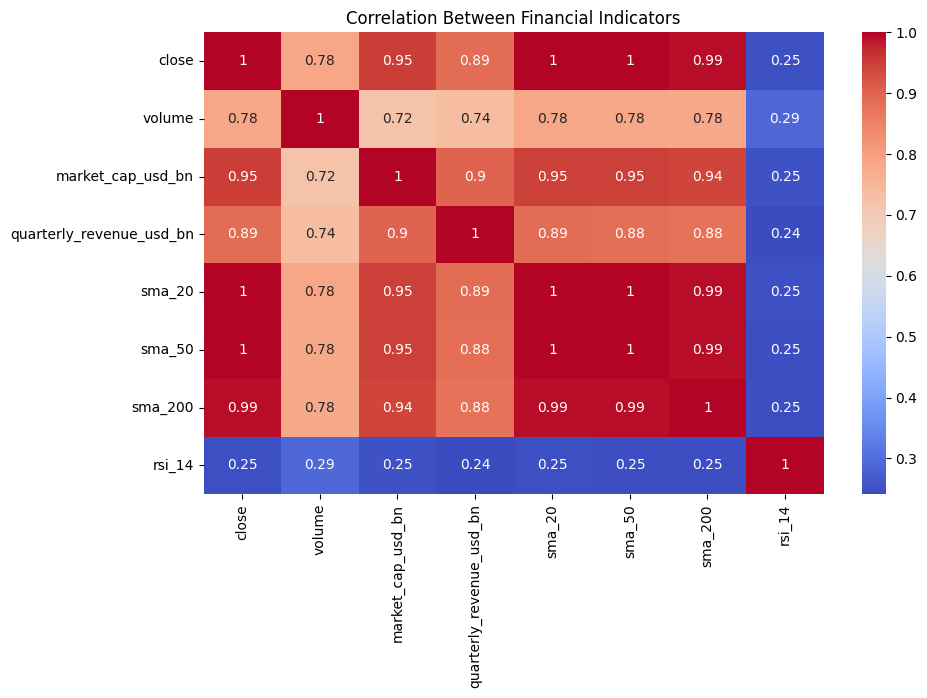

In [22]:
corr = df[['close','volume','market_cap_usd_bn','quarterly_revenue_usd_bn',
           'sma_20','sma_50','sma_200','rsi_14']].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Between Financial Indicators")
plt.show()

The correlation analysis reveals strong relationships between NVIDIA’s stock price, market capitalization, and revenue, highlighting the company’s valuation dependence on financial performance. Technical indicators such as moving averages closely follow price trends, while RSI behaves independently as a momentum indicator.
The main points to be noted are 
1. Market cap and closing price are very closely related
2. Quarterly revenue also affects the market cap largely.

In [23]:
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

features = ['sma_20','sma_50','sma_200','rsi_14','volume']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[features]
y = df['target']

split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.5798022598870056


* The above code compares the closing price for tomorrow with today's closing price and predicts if the price will move up or down
* The features used are trend-indicators(SMA 20,SMA 50, SMA 200), RSI and Volume
* The first 80% of the data is used for training and the last 20% for testing
* Random forest algorithm is used, which builds multiple decision trees and reduces overfitting
* The accuracy gives us the probability that the algorithm can predict the stock movement 

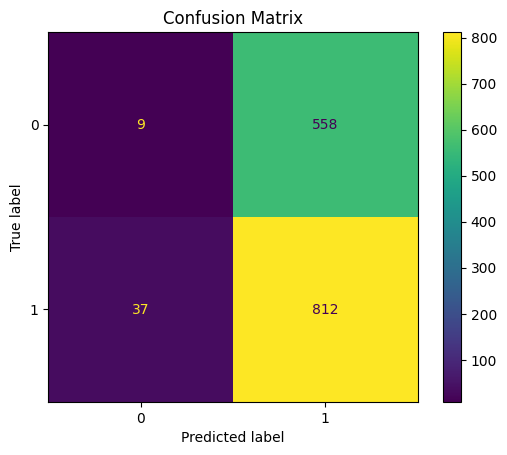

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

* The confusion matrix gives us the values of the predicted values, which are predicted correctly and wrong
* The value in matrix[1,1] is called the True negative, and it shows us the number of correct predictions that the model made that the price will go down ie 12
* The matrix[1,2] is the false positive ie that model predicted the price would go up, instead it was actually down
* The matrix[2,1] is the false negative where the model predicted the price to go down, but instead it went Up
* The matrix[2,2] is the true positive where the model predicted the price to go Up and it went Up

From this, we can understand that the model is more inclined to predict the price to go Up as and very few predictions to go down. 

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.20      0.02      0.03       567
           1       0.59      0.96      0.73       849

    accuracy                           0.58      1416
   macro avg       0.39      0.49      0.38      1416
weighted avg       0.43      0.58      0.45      1416



The accuracy alone is misleading, so it is important to analyze the recall,f1 and support values from which we can understand that the model over-predicts the Upward movement and almost never predicts downward movement

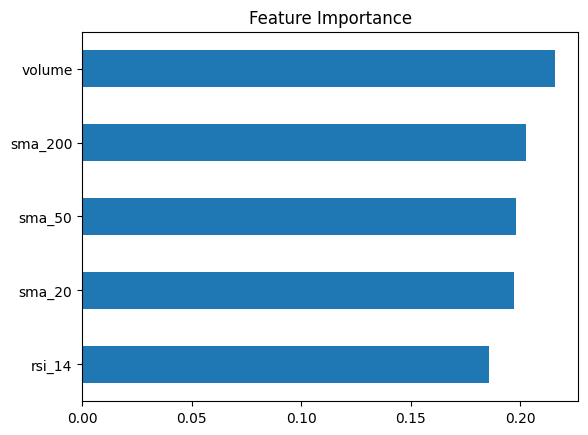

In [26]:
feature_importance = pd.Series(model.feature_importances_, index=features)
feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

This feature graph shows us the features that the model uses the most to predict. 
* The volume feature plays the most important part in prediction follwed by the trend values
* The weightage being almost equally distributed, the model uses a combination of all the features 

The **Key Analysis** we have done in this project.
* Stock price trends across eras
* Volume spikes during AI boom
* Market cap vs revenue relationship
* SMA trend analysis
* Stock split analysis

**KEY INSIGHTS**
* NVIDIA's valuation increased significantly during the AI era
* Stock splits occur during high-growth phases
* Volume is the most important factor for price movement
* Moving averages strongly influence the predictions

**Limitations and Improvements to be done**
* Model struggles with downward predictions
* Deep learning to be added for more accurate predictions